<a href="https://colab.research.google.com/github/1900690/OCR/blob/main/OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# パッケージのインストール（ArUco用のopencv-contrib-pythonを削除）
!pip install yomitoku nest_asyncio pandas lxml

# Colab環境での非同期処理エラーを回避するための設定
import nest_asyncio
nest_asyncio.apply()

import os
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
from yomitoku import DocumentAnalyzer
from yomitoku.data.functions import load_pdf, load_image

# DocumentAnalyzerの初期化
analyzer = DocumentAnalyzer(visualize=True, device="cuda")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.4 MB/s eta 0:00:00


2026-05-14 02:37:30,330 - yomitoku.base - INFO - Initialize TextDetector
INFO:yomitoku.base:Initialize TextDetector


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

2026-05-14 02:37:34,457 - yomitoku.base - INFO - Initialize TextRecognizer
INFO:yomitoku.base:Initialize TextRecognizer


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

2026-05-14 02:37:37,842 - yomitoku.base - INFO - Initialize LayoutParser
INFO:yomitoku.base:Initialize LayoutParser


model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

2026-05-14 02:37:40,263 - yomitoku.base - INFO - Initialize TableStructureRecognizer
INFO:yomitoku.base:Initialize TableStructureRecognizer


model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

2026-05-14 03:02:29,861 - yomitoku.base - INFO - Initialize TextDetector
INFO:yomitoku.base:Initialize TextDetector
2026-05-14 03:02:30,454 - yomitoku.base - INFO - Initialize TextRecognizer
INFO:yomitoku.base:Initialize TextRecognizer
2026-05-14 03:02:31,376 - yomitoku.base - INFO - Initialize LayoutParser
INFO:yomitoku.base:Initialize LayoutParser
2026-05-14 03:02:31,979 - yomitoku.base - INFO - Initialize TableStructureRecognizer
INFO:yomitoku.base:Initialize TableStructureRecognizer
2026-05-14 03:02:33,075 - yomitoku.base - INFO - LayoutParser __call__ elapsed_time: 0.23394393920898438
INFO:yomitoku.base:LayoutParser __call__ elapsed_time: 0.23394393920898438
2026-05-14 03:02:33,078 - yomitoku.base - INFO - LayoutParser wrapper elapsed_time: 0.23692727088928223
INFO:yomitoku.base:LayoutParser wrapper elapsed_time: 0.23692727088928223
2026-05-14 03:02:33,082 - yomitoku.base - INFO - LayoutParser wrapper elapsed_time: 0.24094104766845703
INFO:yomitoku.base:LayoutParser wrapper elapse

✅ CSV保存完了: /content/result_table_0.csv
--- テーブル 0 のプレビュー ---


,月,日,段 数,開花日,品 位,個 数,重量,乱 形 花 落,空,先 尖 り,ャ ツ,裂 果 裂 皮,コ ル ク,窓 空,網 果,小 果 6 v 6,艶 な し,尻 腐,灰 か び,そ の 他
0,5.0,1.0,20.0,5/1,1.0,10.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,2.0,2.0,560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,15.0,5/2,3.0,1.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,13.0,4/1,2.0,5.0,1256.0,NaN,NaN,NaN,NaN,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,6/1,1.0,3.0,256.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


【OCR検出結果（トリミング済）】


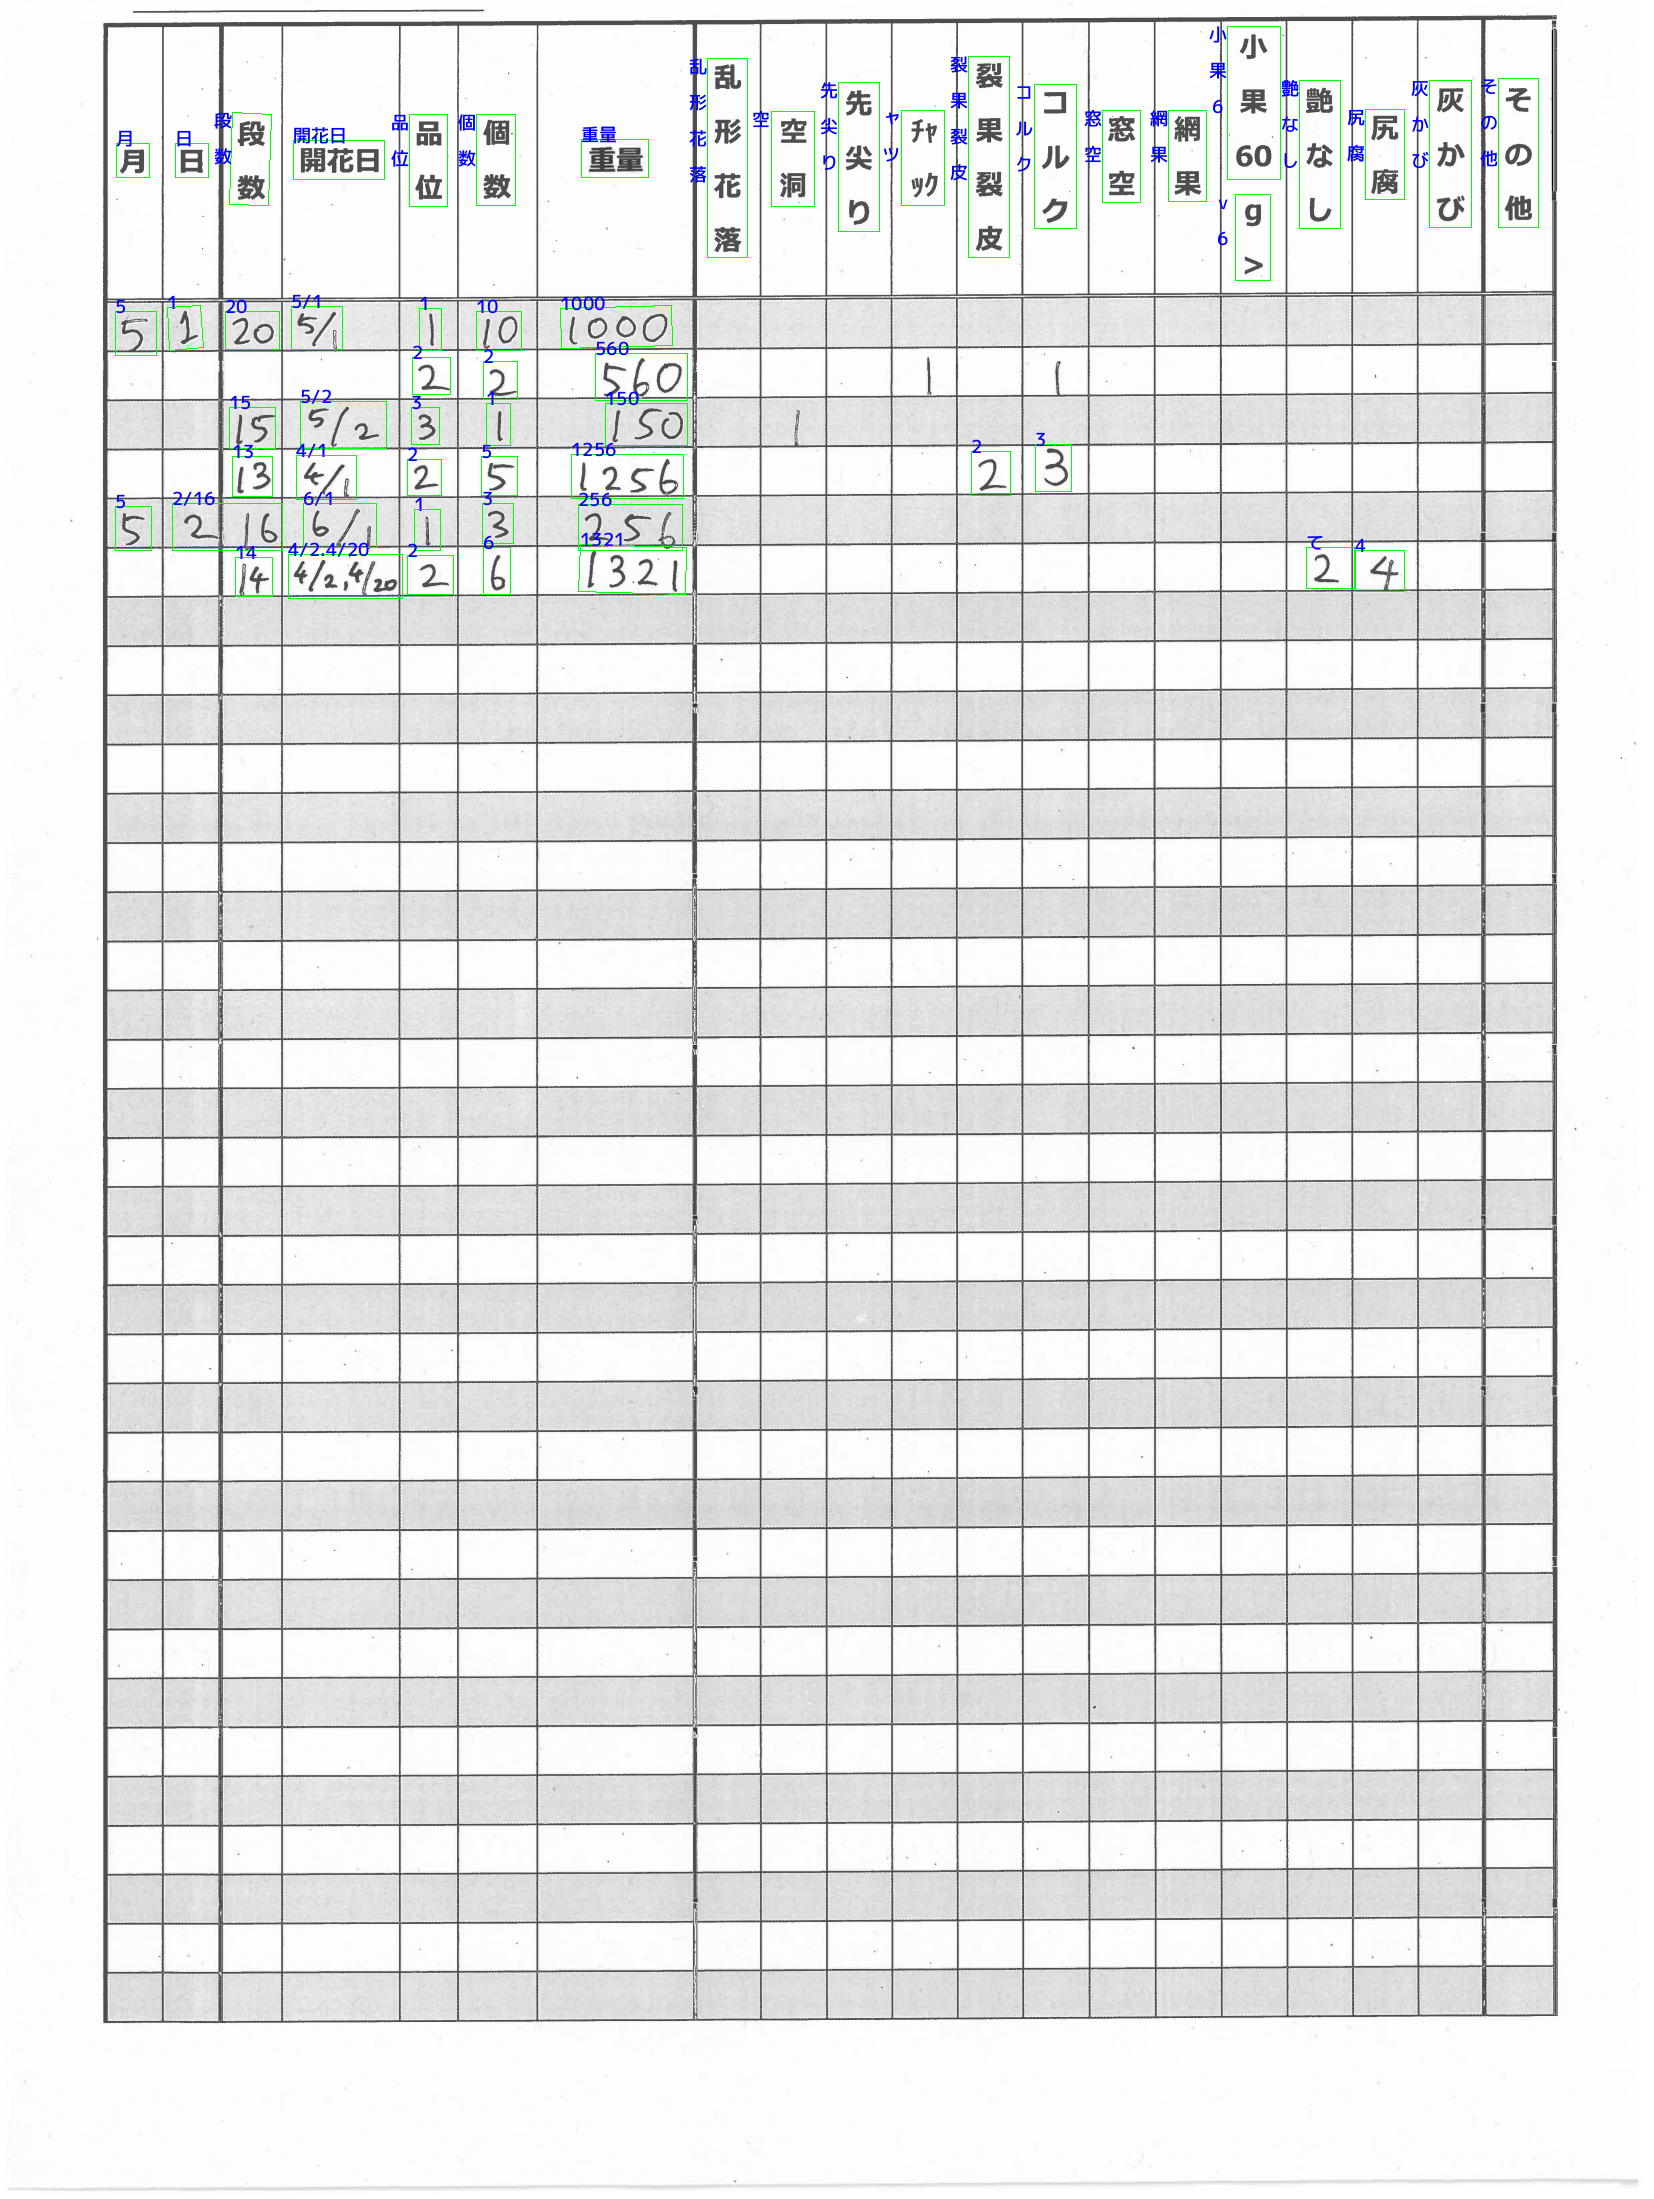

In [12]:
# パッケージのインストール
!pip install yomitoku nest_asyncio pandas lxml

import nest_asyncio
nest_asyncio.apply()

import os
import cv2
import io
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
from yomitoku import DocumentAnalyzer
from yomitoku.data.functions import load_pdf, load_image

# --- 設定項目 ---
# 画像の上部をカットする割合（「A1」などの除外用）
TOP_CROP_RATIO = 0.06
# ----------------

analyzer = DocumentAnalyzer(visualize=True, device="cuda")

# 読み込み対象ファイルのパス
file_path = "/content/SKM_C301i26051411120.pdf"

# ファイル読み込み
ext = os.path.splitext(file_path)[1].lower()
if ext == '.pdf':
    imgs = load_pdf(file_path)
elif ext in ['.png', '.jpg', '.jpeg']:
    imgs = load_image(file_path)
else:
    raise ValueError(f"対応していない拡張子です: {ext}")

img = imgs[0]
if not isinstance(img, np.ndarray):
    img = np.array(img)

# トリミング処理（表外の文字を除外）
h, w = img.shape[:2]
start_row = int(h * TOP_CROP_RATIO)
processed_img = img[start_row:h, 0:w]

# 解析実行
results, ocr_vis, layout_vis = analyzer(processed_img)

# HTML出力
out_html_path = "/content/result.html"
html_content = results.to_html(out_html_path, img=processed_img)
with open(out_html_path, "w", encoding="utf-8") as f:
    f.write(html_content)

# --- CSV変換処理（小数点以下の非表示化） ---
try:
    with open(out_html_path, "r", encoding="utf-8") as f:
        html_str = f.read()

    # ヘッダーを正しく認識させる（header=0）
    tables = pd.read_html(io.StringIO(html_str), header=0)

    if len(tables) > 0:
        for i, df in enumerate(tables):
            csv_path = f"/content/result_table_{i}.csv"

            # 修正点：float_format='%.0f' を追加
            # これにより、数値に含まれる「.0」などの小数点以下の表記をカットして保存します。
            df.to_csv(csv_path, index=False, encoding="utf-8-sig", float_format='%.0f')

            print(f"✅ CSV保存完了: {csv_path}")

            # データ確認（表示上も小数点を除去するために.fillnaとastypeを一時適用して表示）
            print(f"--- テーブル {i} のプレビュー ---")
            display(df.head())
    else:
        print("⚠️ HTML内に表が見つかりませんでした。")

except Exception as e:
    print(f"❌ エラーが発生しました: {e}")

# 可視化画像の保存と表示
cv2.imwrite("/content/result_ocr.jpg", ocr_vis)
cv2.imwrite("/content/result_layout.jpg", layout_vis)
print("【OCR検出結果（トリミング済）】")
cv2_imshow(ocr_vis)